# Import Lib

In [ ]:
!pip install tensorflow wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9686 sha256=2edf1348f237bb3e27bb4c72c4b2229362c2f27e0b35f8cbb3415c7571e8e245
  Stored in directory: /root/.cache/pip/wheels/8a/b8/04/0c88fb22489b0c049bee4e977c5689c7fe597d6c4b0e7d0b6a
Successfully built wget


In [ ]:
import os
from pathlib import Path
import sys

import logging
import sqlite3

import pickle
import matplotlib as plt
import numpy as np
import tensorflow as tf

In [ ]:
cd /content/drive/MyDrive/CPV

/content/drive/MyDrive/CPV


## Path

In [ ]:
base_dir = Path(os.getcwd())

model_dir = base_dir / "model"
# Deep learning
VGG_model_dir = model_dir / "VGG_model"
base_CNN_model_dir = model_dir / "base_CNN_model_dir"

# Machine learning:
ml_model = model_dir / "ml_model"


data_dir = base_dir / "data"
data_raw = data_dir / "raw_data"
data_processed = data_dir / "processed_data"

db_path = base_dir / "DB_logger.db"

manager_dir = [
    data_dir,
    data_raw,
    data_processed,
    model_dir,
    VGG_model_dir,
    base_CNN_model_dir,
    ml_model
]
for dir_path in manager_dir:
  try:
    dir_path.mkdir(parents = True, exist_ok = True)
  except Exception as e:
    print(f"\033[31mLỗi khởi tạo thư mục {dir_path}{e}\033[0m")

print(f"{base_dir}\n{data_dir}\n{data_processed}\n{data_raw}\n{db_path}")

/content/drive/MyDrive/CPV
/content/drive/MyDrive/CPV/data
/content/drive/MyDrive/CPV/data/processed_data
/content/drive/MyDrive/CPV/data/raw_data
/content/drive/MyDrive/CPV/DB_logger.db


## Setup Database to save Log report
Danh sách các mức độ log

| Mức độ (Level) | Giá trị số | Ý nghĩa | Khi nào nên dùng |
| :---: | :---: | :---: | :---: |
| DEBUG | 10 | Chi tiết nhất | Dùng khi cần tìm lỗi trong quá trình phát triển (vết luồng code).|
| INFO | 20 | Thông tin thông thường | Xác nhận mọi thứ đang chạy đúng tiến độ (ví dụ: "Đã tải xong file"). |
| WARNING | 30 | Cảnh báo | Phát hiện bất thường nhỏ, hệ thống vẫn chạy được nhưng cần lưu ý. |
| ERROR | 40 | Lỗi nghiêm trọng | Một chức năng bị sập (ví dụ: mất mạng không tải được file), cần xử lý ngay. |
| CRITICAL | 50 | Lỗi chí mạng | Toàn bộ ứng dụng bị sập, không thể tiếp tục chạy. |

In [ ]:
class DBHandler(logging.Handler):
  def __init__(self, db_path):
    super().__init__()
    self.db_path = db_path
    self.init_db()

  def init_db(self):
    conn = sqlite3.connect(self.db_path)
    cursor = conn.cursor()
    cursor.execute('''
            CREATE TABLE IF NOT EXISTS logs (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
                level TEXT,
                logger TEXT,
                message TEXT
            )
        ''')
    conn.commit()
    conn.close()

  def emit(self, record):
    log_entry = self.format(record)
    try:
      conn = sqlite3.connect(self.db_path)
      cursor = conn.cursor()
      cursor.execute('''
        INSERT INTO logs (level, logger, message)
        VALUES (?, ?, ?)
      ''', (record.levelname, record.name, log_entry)
      )
      conn.commit()
      conn.close()
    except Exception:
      self.handleError(record)

formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')

# Tạo Handler xuất ra màn hình (Console)
console_handler = logging.StreamHandler(sys.stdout)
console_handler.setFormatter(formatter)

# Tạo Handler lưu vào SQLite
sqlite_handler = DBHandler(db_path=db_path)
sqlite_handler.setFormatter(formatter)

logger = logging.getLogger("CPV_log_record")
logger.setLevel(logging.INFO)

logger.addHandler(console_handler)
logger.addHandler(sqlite_handler)

In [ ]:
# --- Chạy thử nghiệm ---
logger.info("Hệ thống bắt đầu ghi log.")
logger.warning("Cảnh báo thử nghiệm!")

2026-09-14 17:45:15,918 - INFO - Hệ thống bắt đầu ghi log.


INFO:CPV_log_record:Hệ thống bắt đầu ghi log.


2026-09-14 17:45:15,944 - WARNING - Cảnh báo thử nghiệm!


# Download Dataset from link

In [ ]:
link = "https://d17h27t6h515a5.cloudfront.net/topher/2017/February/5898cd6f_traffic-signs-data/traffic-signs-data.zip"

import wget

filename = "traffic-signs-data.zip"
file_path = data_raw / filename

if (file_path.exists()):
  logger.info(f"Dataset '{filename}' đã tồn tại sẵn trong thư mục '{data_raw}'. Bỏ qua bước tải về.")
else:
  try:
    logger.info(f"Bắt đầu tải Dataset từ liên kết: {link}")
    wget.download(link, out = str(file_path))
    print()
    logger.info(f"Tải Dataset thành công! File đã được lưu tại: {file_path}")
  except Exception as e:
    logger.error(f"Quá trình tải Dataset thất bại. Chi tiết lỗi: {e}")

ModuleNotFoundError: No module named 'wget'

In [ ]:
import zipfile

if not file_path.exists():
  logger.error(f"Không tìm thấy file zip tại: {data_raw}. Vui lòng chạy bước tải dữ liệu trước!")
else:
  try:
    with zipfile.ZipFile(file_path, 'r') as data_file:
      data_file.extractall(data_raw)
    logger.info(f"Giải nén thành công! Toàn bộ dữ liệu nằm tại: {data_raw}")
  except zipfile.BadZipFile:
    logger.error(f"File '{filename}' bị hỏng (BadZipFile). Có thể quá trình tải về trước đó bị ngắt quãng.")
  except Exception as e:
    logger.error(f"Quá trình giải nén thất bại. Chi tiết lỗi:{e}")

2026-09-14 18:22:25,338 - INFO - Giải nén thành công! Toàn bộ dữ liệu nằm tại: /content/drive/MyDrive/CPV/data/raw_data


INFO:CPV_log_record:Giải nén thành công! Toàn bộ dữ liệu nằm tại: /content/drive/MyDrive/CPV/data/raw_data


# Tiền xử lý dữ liệu

In [ ]:
train_file = data_processed/ "train.p"
test_file = data_processed / "test.p"
valid_file = data_processed / "valid.p"

def Read_file(data_file):
  try:
    with open(data_file, "rb") as f:
      dfile = pickle.load(f)
      logger.info(f"Quá trình đọc {data_file} thành công!")
      return dfile
  except Exception as e:
    logger.error(f"Quá trình đọc {data_file} thất bại. Chi tiết lỗi:{e}")

train = Read_file(train_file)
test = Read_file(test_file)
valid = Read_file(valid_file)

2026-09-18 15:03:34,824 - INFO - Quá trình đọc /content/drive/MyDrive/CPV/data/raw_data/train.p thành công!


INFO:CPV_log_record:Quá trình đọc /content/drive/MyDrive/CPV/data/raw_data/train.p thành công!


2026-09-18 15:03:36,906 - INFO - Quá trình đọc /content/drive/MyDrive/CPV/data/raw_data/test.p thành công!


INFO:CPV_log_record:Quá trình đọc /content/drive/MyDrive/CPV/data/raw_data/test.p thành công!


2026-09-18 15:03:38,490 - INFO - Quá trình đọc /content/drive/MyDrive/CPV/data/raw_data/valid.p thành công!


INFO:CPV_log_record:Quá trình đọc /content/drive/MyDrive/CPV/data/raw_data/valid.p thành công!


## Khám phá cấu trúc dữ liệu ảnh

In [ ]:
Label_Names = {
  0:'Speed limit (20km/h)',
  1: 'speed limit (30km/h)',
  2: 'Speed limit (50km/h)',
  3: 'Speed limit (60km/h)',
  4: 'Speed limit (70km/h)',
  5: 'Speed limit (80km/h)',
  6: 'End of speed limit (80km/h)',
  7: 'speed limit (100km/h)',
  8: 'Speed limit (120km/h)',
  9: 'No passing',
  10: 'No passing for vehicles over 3.5 metric tons',
  11: 'Right-of-way at the next intersection',
  12: 'priority road',
  13: 'yield',
  14: 'Stop',
  15: 'No vehicles',
  16: 'Vehicles over 3.5 metric tons prohibited',
  17: 'No entry',
  18: 'General caution',
  19: 'Dangerous curve to the left',
  20: 'Dangerous curve to the right',
  21: 'Double curve',
  22: 'Bumpy road',
  23: 'Slippery road',
  24: 'Road narrows on the right',
  25: 'Road work',
  26: 'Traffic signals',
  27: 'Pedestrians',
  28: 'Children crossing',
  29: 'Bicycles crossing',
  30: 'Beware of ice/snow',
  31: 'Wild animals crossing',
  32: 'End of all speed and passing limits',
  33: 'Turn right ahead',
  34: 'Turn left ahead',
  35: 'Ahead only',
  36: 'Go straight or right',
  37: 'Go straight or left',
  38: 'Keep right',
  39: 'Keep left',
  40: 'Roundabout mandatory',
  41: 'End of no passing',
  42: 'End of no passing by vehicles over 3.5 metric tons'}

In [ ]:
trainX = train["features"]
trainY = train["labels"]
print(f"train:{trainX.shape},{trainY.shape}")

testX = test["features"]
testY = test["labels"]
print(f"test:{testX.shape},{testY.shape}")

validX = valid["features"]
validY = valid["labels"]
print(f"valib:{validX.shape},{validY.shape}")

train:(34799, 32, 32, 3),(34799,)
test:(12630, 32, 32, 3),(12630,)
valib:(4410, 32, 32, 3),(4410,)


'speed limit (30km/h)'

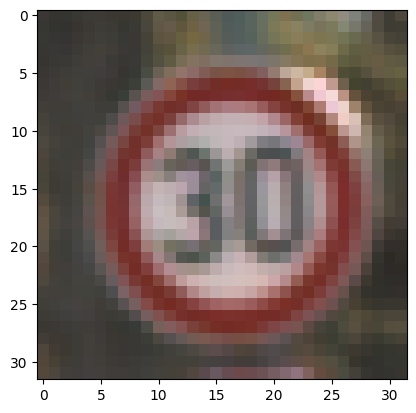

In [ ]:
plt.pyplot.imshow(trainX[3110])
Label_Names[trainY[3110]]

## Chuẩn hóa dữ liệu (normalization): Chuyển giá trị pixel về khoảng [0, 1]
Với CNN tự xây và huấn luyện từ đầu, một lựa chọn đơn giản là đổi ảnh sang số thực rồi chia pixel cho 255, đưa giá trị về khoảng [0,1].

In [ ]:
trainX = trainX.astype("float") / 255.0
validX = validX.astype("float") / 255.0
testX = testX.astype("float") / 255.0

In [ ]:
trainX[0]

array([[[0.10980392, 0.09803922, 0.09411765],
        [0.10588235, 0.09411765, 0.09019608],
        [0.10588235, 0.09411765, 0.08627451],
        ...,
        [0.1254902 , 0.10980392, 0.09411765],
        [0.12156863, 0.10588235, 0.09803922],
        [0.12156863, 0.10588235, 0.10196078]],

       [[0.11372549, 0.10196078, 0.09803922],
        [0.10588235, 0.09803922, 0.09019608],
        [0.10588235, 0.09803922, 0.09019608],
        ...,
        [0.1254902 , 0.10980392, 0.09411765],
        [0.12156863, 0.10588235, 0.09411765],
        [0.11764706, 0.10588235, 0.09803922]],

       [[0.10980392, 0.10196078, 0.10196078],
        [0.10588235, 0.09803922, 0.09019608],
        [0.10196078, 0.09803922, 0.09019608],
        ...,
        [0.1254902 , 0.10980392, 0.09411765],
        [0.12156863, 0.10588235, 0.09411765],
        [0.11764706, 0.10588235, 0.09803922]],

       ...,

       [[0.10588235, 0.09411765, 0.09019608],
        [0.10980392, 0.09803922, 0.09411765],
        [0.11764706, 0

## Xáo trộn (shuffle) dữ liệu

In [ ]:
# Xáo trộn (shuffle) dữ liệu để đảm bảo tính tổng quát khi huấn luyện
from sklearn.utils import shuffle

trainX, trainY = shuffle(trainX, trainY)

'Speed limit (70km/h)'

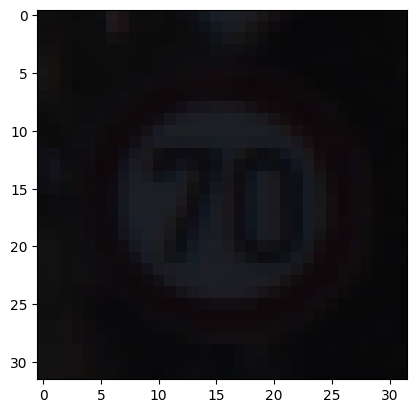

In [ ]:
# Kiểm tra lại xem tập train đã xáo trộn (shuffle) chưa
plt.pyplot.imshow(trainX[3110]) # True
Label_Names[trainY[3110]]

## Chuyển nhãn (label) sang dạng One hot encoding

In [ ]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()

trainY = lb.fit_transform(trainY)
validY = lb.fit_transform(validY)

In [ ]:
print(valid['labels'][103],'',validY[103])

31  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0]


# Xây dựng CNN theo kiến trúc VGG16

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import concatenate

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import SGD

In [ ]:
VGG_model = Sequential()

In [ ]:
width = 32
height = 32
classes = 43
shape = (width, height, 3)

## Block 1

### Conv2d(32) + Activation function "relo" + BatchNormalization
Chạy 2 lần code này

#### Layer 1 Convolution
Tự động học cách trích xuất đặc trưng (như đường nét, hình dạng) từ ảnh

In [ ]:
VGG_model.add(Conv2D(32, (3, 3), padding = 'same', input_shape = shape))
# trích xuất các đặc trưng theo chiều dọc, ngang của bức ảnh
# đầu vào là 1 input: 1 bức ảnh có chiều dài là 32, chiều rông là 32 và có 3 tấm phân theo RGB (red, green, blue) (32,32,3)

#### Layer 2 Activation "relu"

In [ ]:
VGG_model.add(Activation('relu'))

#### Layer 3 Batch Normalization

In [ ]:
VGG_model.add(BatchNormalization())

### Model MAX Pooling

In [ ]:
VGG_model.add(MaxPooling2D(pool_size=(2,2)))

## Block 2


### Conv2d(64) + Activation function "relo" + BatchNormalization
Chạy 2 lần

In [ ]:
VGG_model.add(Conv2D(64, (3, 3), padding='same'))
VGG_model.add(Activation('relu'))
VGG_model.add(BatchNormalization())

### Model Max Pooling

In [ ]:
VGG_model.add(MaxPooling2D(pool_size=(2, 2)))

## Block 3
Trong kiến trúc mạng CNN (Convolutional Neural Network), việc chuyển đổi dữ liệu thành dạng vector trước khi đưa vào lớp Fully Connected (mạng kết nối đầy đủ) là một bước bắt buộc.
Sau Block 2 thì output đang là ((8 * 8)* 64). Mốt bảo vào CNN thì ta phải trải thành 1 Vecto (Số bất kì* 1)
Ta phải dùng Flattening để giúp duỗi các ma trận 3 chiều (height x width x channels) thành một vector phẳng 1 chiều

In [ ]:
VGG_model.add(Flatten())

Hiện tại output của model là (4096 * 1) thì muốn đưa về phần loại 43 lớp thì phải thông qua 1 hàm Dense(số bất kì).

In [ ]:
VGG_model.add(Dense(512))

Lưu ý: trong Fully Connected Network yêu cầu phải có 1 hàm activation ở phí sau hàm Dense().

In [ ]:
VGG_model.add(Activation("relu"))

In [ ]:
VGG_model.add(BatchNormalization())

In [ ]:
VGG_model.add(Dense(classes))

In [ ]:
VGG_model.add(Activation("softmax"))

## Model summary

In [ ]:
VGG_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 43)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,188,107 (8.35 MB)

 Trainable params: 2,186,699 (8.34 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
# dùng để xóa đi lớp layer nếu thừa hoạch thêm dư layer
VGG_model.pop()

<Conv2D name=conv2d, built=True>

## Tăng cường dữ liệu (Data Augmentation):

In [ ]:
agu = ImageDataGenerator(rotation_range=0.18, zoom_range=0.15, width_shift_range=0.2, height_shift_range=0.2, horizontal_flip=True)

## Cấu hình mô hình và huấn luyện

In [ ]:
learning_rate = 0.01
epochs = 10
batch_size = 64
opt = SGD(learning_rate=learning_rate, momentum=0.9)

## Cấu hình mô hình và huấn luyện

In [ ]:
# Metric
# Sự khác biệt giữa Macro và Weighted:
#     Macro: Tính toán chỉ số độc lập cho từng lớp rồi lấy trung bình cộng.
#            Rất tốt để đánh giá nếu bạn muốn các lớp nhỏ (ít dữ liệu) được coi trọng ngang hàng với lớp lớn.
#     weighted: Tính toán chỉ số có trọng số dựa trên số lượng mẫu (support) của từng lớp.
#               Phù hợp khi tập dữ liệu bị lệch/mất cân bằng (imbalanced data).

full_metrics = [
    'accuracy',   # Tỉ lệ chính xác tổng thể

    # 1. F1-Score (Macro & Weighted)
    tf.keras.metrics.F1Score(average='macro', name='f1_macro'),
    tf.keras.metrics.F1Score(average='weighted', name='f1_weighted'),

    # 2. Precision (Macro & Weighted)
    tf.keras.metrics.Precision(name='precision_macro'),
    tf.keras.metrics.Precision(name='precision_weighted'),

    # 3. Recall (Macro & Weighted)
    tf.keras.metrics.Recall(name='recall_macro'),
    tf.keras.metrics.Recall(name='recall_weighted')
]

In [ ]:
VGG_model.compile(
    optimizer = opt,
    loss = "categorical_crossentropy",
    metrics = full_metrics
)

In [ ]:
class LoggingCallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        logger.info("Bắt đầu quá trình huấn luyện model VGG...")

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        # Lấy các thông số chính từ logs
        loss = logs.get('loss')
        accuracy = logs.get('accuracy')
        val_loss = logs.get('val_loss')
        val_accuracy = logs.get('val_accuracy')

        log_msg = f"Epoch {epoch + 1}/{self.params['epochs']} - loss: {loss:.4f} - accuracy: {accuracy:.4f}"
        if val_loss is not None:
            log_msg += f" - val_loss: {val_loss:.4f} - val_accuracy: {val_accuracy:.4f}"

        logger.info(log_msg)

    def on_train_end(self, logs=None):
        logger.info("Quá trình huấn luyện model kết thúc thành công!")

In [ ]:
# Khởi tạo callback ghi log
logging_callback = LoggingCallback()

# Tiến hành huấn luyện mô hình với dữ liệu đã được tăng cường (Augmentation)
H = VGG_model.fit(
    agu.flow(trainX, trainY, batch_size=batch_size),
    validation_data=(validX, validY),
    steps_per_epoch=len(trainX) // batch_size,
    epochs=epochs,
    callbacks=[logging_callback],
    verbose=1
)

2026-09-18 16:46:11,091 - INFO - Bắt đầu quá trình huấn luyện model VGG...


INFO:CPV_log_record:Bắt đầu quá trình huấn luyện model VGG...


Epoch 1/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.3036 - f1_macro: 0.2266 - f1_weighted: 0.2912 - loss: 2.6000 - precision_macro: 0.5768 - precision_weighted: 0.5768 - recall_macro: 0.1603 - recall_weighted: 0.16032026-09-18 16:51:37,476 - INFO - Epoch 1/10 - loss: 1.9030 - accuracy: 0.4465 - val_loss: 1.6932 - val_accuracy: 0.5422


INFO:CPV_log_record:Epoch 1/10 - loss: 1.9030 - accuracy: 0.4465 - val_loss: 1.6932 - val_accuracy: 0.5422


543/543 ━━━━━━━━━━━━━━━━━━━━ 326s 595ms/step - accuracy: 0.4465 - f1_macro: 0.3682 - f1_weighted: 0.4362 - loss: 1.9030 - precision_macro: 0.7200 - precision_weighted: 0.7200 - recall_macro: 0.2942 - recall_weighted: 0.2942 - val_accuracy: 0.5422 - val_f1_macro: 0.3826 - val_f1_weighted: 0.5060 - val_loss: 1.6932 - val_precision_macro: 0.6964 - val_precision_weighted: 0.6964 - val_recall_macro: 0.4619 - val_recall_weighted: 0.4619
Epoch 2/10
  1/543 ━━━━━━━━━━━━━━━━━━━━ 3:34 395ms/step - accuracy: 0.7344 - f1_macro: 0.4423 - f1_weighted: 0.7012 - loss: 0.8910 - precision_macro: 0.8511 - precision_weighted: 0.8511 - recall_macro: 0.6250 - recall_weighted: 0.6250

...

INFO:CPV_log_record:Epoch 9/10 - loss: 0.1279 - accuracy: 0.9572 - val_loss: 0.5339 - val_accuracy: 0.8574


543/543 ━━━━━━━━━━━━━━━━━━━━ 287s 528ms/step - accuracy: 0.9572 - f1_macro: 0.9398 - f1_weighted: 0.9569 - loss: 0.1279 - precision_macro: 0.9668 - precision_weighted: 0.9668 - recall_macro: 0.9494 - recall_weighted: 0.9494 - val_accuracy: 0.8574 - val_f1_macro: 0.7536 - val_f1_weighted: 0.8523 - val_loss: 0.5339 - val_precision_macro: 0.8791 - val_precision_weighted: 0.8791 - val_recall_macro: 0.8478 - val_recall_weighted: 0.8478
Epoch 10/10
  1/543 ━━━━━━━━━━━━━━━━━━━━ 3:45 417ms/step - accuracy: 0.9844 - f1_macro: 0.5659 - f1_weighted: 0.9844 - loss: 0.0852 - precision_macro: 0.9839 - precision_weighted: 0.9839 - recall_macro: 0.9531 - recall_weighted: 0.95312026-09-18 17:11:53,244 - INFO - Epoch 10/10 - loss: 0.0852 - accuracy: 0.9844 - val_loss: 0.5363 - val_accuracy: 0.8560


INFO:CPV_log_record:Epoch 10/10 - loss: 0.0852 - accuracy: 0.9844 - val_loss: 0.5363 - val_accuracy: 0.8560


543/543 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9844 - f1_macro: 0.5659 - f1_weighted: 0.9844 - loss: 0.0852 - precision_macro: 0.9839 - precision_weighted: 0.9839 - recall_macro: 0.9531 - recall_weighted: 0.9531 - val_accuracy: 0.8560 - val_f1_macro: 0.7550 - val_f1_weighted: 0.8512 - val_loss: 0.5363 - val_precision_macro: 0.8751 - val_precision_weighted: 0.8751 - val_recall_macro: 0.8465 - val_recall_weighted: 0.8465
2026-09-18 17:11:53,284 - INFO - Quá trình huấn luyện model kết thúc thành công!


INFO:CPV_log_record:Quá trình huấn luyện model kết thúc thành công!


In [ ]:
VGG_model_name = VGG_model_dir / "VGG16_model.h5"
VGG_model.save(VGG_model_name)

In [ ]:
saved_model = VGG_model_dir / "VGG16_model.h5"

# Xây dựng CNN base model

kiến trúc nền tảng để đánh giá VGG

# Machine learning algorithms

1. SVM (Support Vector Machines): Phân chia mặt phẳng siêu việt tốt cho dữ liệu nhiều chiều.
2. Random Forest / Decision Trees: Tập hợp các cây quyết định.
3. KNN (K-Nearest Neighbors): So sánh khoảng cách các đặc trưng gần nhất.